# CLIP Classification
CLIP (Contrastive Language-Image Pretraining) enables **zero-shot classification** by comparing an input image to a set of textual descriptions and selecting the most relevant one. Unlike traditional classifiers that require training on specific labeled datasets, CLIP generalizes across domains without additional fine-tuning.

## Steps in CLIP Classification
1. **Image Encoding**
- The input image is passed through the **image encoder** (either a Vision Transformer or ResNet).
- The encoder extracts visual features and converts the image into a **feature vector (embedding)** in a high-dimensional space.

2. **Text Encoding**
 - A set of possible class labels (e.g., “a cat”, “a dog”, “a car”) is converted into complete **natural language prompts** like:
    - “A photo of a cat.”
    - “A photo of a dog.”
    - “A photo of a car.”
 - These textual descriptions are passed through the **text encoder** (a Transformer model), converting them into **text embeddings**.

3. **Computing Similarities**
 - The image embedding is compared with all the text embeddings using a **cosine similarity** measure.
 - The **text embedding with the highest similarity score** is chosen as the predicted label.

4. **Classification Output**
 - The model returns the most similar label along with a confidence score.

In [1]:
#! pip install tqdm git+https://github.com/openai/CLIP.git

import matplotlib.pyplot as plt
import numpy as np
import torch
import clip
from tqdm.notebook import tqdm
import os
from torchvision.datasets import CIFAR10
from torchvision import transforms

# Load the model and Cifar-10 Dataset

In [2]:
device = torch.device("cuda:0")

In [3]:
# Load in a ViT CLIP model
model, preprocess = clip.load("ViT-B/32")

In [4]:
# Load in CIFAR-10 dataset
cifar10 = CIFAR10(root="./data", download=True, train=False, transform=preprocess)
loader = torch.utils.data.DataLoader(cifar10, batch_size=32, shuffle=False)

Files already downloaded and verified


The following code defines the CIFAR-10 templates and classes, to capture possible language augmentations for image descriptions.

In [5]:
# Define CIFAR-10 templates and classes, to capture possible language augmentations for image descriptions
cifar10_templates = [
    'a photo of a {}.',
    'a blurry photo of a {}.',
    'a black and white photo of a {}.',
    'a low contrast photo of a {}.',
    'a high contrast photo of a {}.',
    'a bad photo of a {}.',
    'a good photo of a {}.',
    'a photo of a small {}.',
    'a photo of a big {}.',
    'a photo of the {}.',
    'a blurry photo of the {}.',
    'a black and white photo of the {}.',
    'a low contrast photo of the {}.',
    'a high contrast photo of the {}.',
    'a bad photo of the {}.',
    'a good photo of the {}.',
    'a photo of the small {}.',
    'a photo of the big {}.',
]

cifar10_classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]

# Generating Zero-Shot Classification Weights for CIFAR-10 using CLIP

Our goal is to generate **zero-shot classification weights** for CIFAR-10 classes using text templates and the CLIP model. These weights allow us to classify images into one of the CIFAR-10 categories without explicitly training on them.

## How It Works
The `zeroshot_classifier` function processes each class name from a given list (e.g., airplane, automobile, bird, etc.) and generates corresponding text embeddings. The steps are as follows:

1. **Generating Text Descriptions**:

 - For each class name, multiple textual descriptions are created using predefined templates (e.g., "A photo of a {class_name}.").
2. **Encoding Text with CLIP:**
 - The generated descriptions are **tokenized** and passed through the **CLIP text encoder** to obtain embeddings.
 - Each embedding is **L2-normalized** to ensure consistency across different class descriptions.

3. **Averaging and Normalization:**
 - The embeddings for all descriptions of a given class are **averaged** to create a representative embedding for that class.
 - The resulting class embedding is **normalized** again to maintain a uniform scale.

4. **Constructing the Classification Matrix:**
 - The final embeddings for all classes are **stacked** into a tensor, forming a classification matrix.
 - Each **column** in this matrix corresponds to a distinct CIFAR-10 class, and the values represent the **zero-shot classification weights**.
   
## Why This Works?
 - **Zero-Shot Capability**: CLIP has been trained on vast amounts of image-text pairs, allowing it to generalize to unseen classes.
 - **Open-Vocabulary Classification**: Unlike traditional classifiers, we don’t need explicit labels—just meaningful text descriptions.
 - **Efficient Representation**: Averaging multiple descriptions improves robustness, and normalization ensures consistency.

In [12]:
def zeroshot_classifier(class_names, templates):
    """
    Generates zero-shot classification weights by averaging the embedded templates of class names.

    Parameters:
    class_names (list): A list of names of the classes.
    templates (list): A list of templates to be used in the formatting of class names.

    Returns:
    Tensor: A tensor containing the zero-shot classification weights.
    """
    with torch.no_grad():
        classification_weights = []
        for class_name in class_names:
            formatted_texts = [template.format(class_name) for template in templates]
            tokenized_texts = clip.tokenize(formatted_texts).cuda() # 18, 77

            # Get embeddings using the CLIP model's text encoder and normalize
            class_embeddings = model.encode_text(tokenized_texts)   # 18, 512
            class_embeddings /= class_embeddings.norm(dim=-1, keepdim=True)  # 18, 512

            # Average the embeddings and normalize again
            average_embedding = sum(class_embeddings)    # 512
            average_embedding /= average_embedding.norm()

            # Store the averaged and normalized embedding
            classification_weights.append(average_embedding)

        classification_weights = torch.stack(classification_weights, dim=1).cuda()
    return classification_weights   # 512

In [13]:
zeroshot_weights = zeroshot_classifier(cifar10_classes, cifar10_templates)

# Zero-shot prediction
In evaluating model performance, we often measure not just the top-1 accuracy (the most confident prediction) but also the top-k accuracy. This helps assess whether the model is predicting the correct class within its top-k most confident choices, even if the highest-confidence prediction is incorrect.

### How It Works:
- **Identify Top-K Predictions**: Extract the indices of the k highest values in the model's prediction tensor.
- **Compare with Ground Truth**: Check if the correct label is present among the top-k predictions for each sample.
- **Compute Accuracy**: Count the number of correct predictions for each k and normalize by the total number of samples.
- **Return Accuracy Scores**: The final result is a list of accuracy values, one for each k

In [14]:
def accuracy(predictions, targets, topk=(1,)):
    """
    Calculate the accuracy of the top k predictions

    Parameters:
    predictions (Tensor): The model output.
    targets (Tensor): Ground truth labels.
    topk (tuple, optional): Tuple indicating the top k predictions to consider for accuracy.

    Returns:
    list: A list of accuracies for each k in topk.
    """

    # Get the top k predictions and their indices
    top_k_preds_indices = predictions.topk(max(topk), dim=1, largest=True, sorted=True)[1].t()

    # Compare the top k predictions with the targets to see if they are correct
    correct_comparisons = top_k_preds_indices.eq(targets.view(1, -1).expand_as(top_k_preds_indices))

    accuracies = []
    for k in topk:
        # Get the number of correct predictions in the top k
        correct_in_top_k = correct_comparisons[:k].reshape(-1).float().sum(0, keepdim=True)

        # Move the correct count to cpu, convert to numpy and then to native Python float
        accuracies.append(float(correct_in_top_k.cpu().numpy()))

    return accuracies

In [36]:
def visualize_predictions(images, actual_labels, predicted_labels, class_names, num_samples=1):
    mu, sigma = torch.tensor((0.48145466, 0.4578275, 0.40821073)), torch.tensor((0.26862954, 0.26130258, 0.27577711))
    mu_, sigma_ = -mu / sigma, 1 / sigma
    images = transforms.Normalize(mu_, sigma_)(images)
    num_samples = min(num_samples, images.shape[0])
    grid_size = int(np.ceil(np.sqrt(num_samples)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 2, grid_size * 2))
    axes = axes.flatten()
    for i in range(num_samples):
        ax = axes[i]
        img = np.transpose(images[i].cpu().numpy(), (1, 2, 0))
        ax.imshow(img)
        ax.set_title(f"Actual: {class_names[actual_labels[i]]}\nPredicted: {class_names[predicted_labels[i]]}", fontsize=8)
        ax.axis('off')
        # Hide any remaining axes
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

For each batch, we perform the following steps:

 - Move Data to GPU: Both the image batch and corresponding labels are transferred to the GPU for faster processing.
 - Extract & Normalize Features: Images are encoded by the model to obtain feature representations, which are then normalized.
 - Compute Logits: The dot product between image features and zeroshot_weights is used to generate class logits.
 - Determine Predictions: The top-1 prediction (highest probability class) is extracted from the logits.
 - Visualize Results: visualize_predictions is called to display the image, its true label, and the predicted label.
 - Calculate Accuracy: Both top-1 and top-5 accuracies are computed for the batch.
 - Aggregate Results: After processing all batches, overall top-1 and top-5 accuracies are obtained by dividing the accumulated correct predictions by the total number of samples.

In [40]:
def evaluate_and_visualize_model(model, loader, zeroshot_weights, visualize_predictions, accuracy, cifar10_classes, max_visualizations=1):
    """
    Evaluate and visualize the model's predictions.

    Parameters:
    - model: the model to be evaluated
    - loader: DataLoader for the evaluation dataset
    - zeroshot_weights: the weights used in zero-shot classification
    - visualize_predictions: function to visualize the model's predictions
    - accuracy: function to calculate the accuracy of the model's predictions
    - cifar10_classes: list of class names in CIFAR-10
    - max_visualizations: maximum number of predictions to visualize
    """
    predictions = []
    model.eval()
    with torch.no_grad():
        top1_accuracy, top5_accuracy, total_samples = 0., 0., 0.
        visualization_count = 0

        for batch_index, (image_batch, true_labels) in enumerate(loader):
            # Send image_batch and true_labels to cuda device
            image_batch, true_labels = image_batch.to(device), true_labels.to(device)

            # Generate image features and normalize them
            image_features = model.encode_image(image_batch)
            logits = 100. * image_features @ zeroshot_weights

            _, top_prediction = logits.topk(1, dim=1)

            predictions.append(top_prediction.cpu())

            if visualization_count < max_visualizations:
                visualize_predictions(image_batch, true_labels.cpu(), top_prediction.cpu().squeeze(), cifar10_classes, 30)
                visualization_count += 1

            # Measure and accumulate accuracy
            batch_top1_acc, batch_top5_acc = accuracy(logits, true_labels, topk=(1,5))
            top1_accuracy += batch_top1_acc
            top5_accuracy += batch_top5_acc
            total_samples += image_batch.size(0)

        # Calculate the overall top-1 and top-5 accuracy
        overall_top1_accuracy = (top1_accuracy / total_samples) * 100
        overall_top5_accuracy = (top5_accuracy / total_samples) * 100

        print(f"Top-1 accuracy: {overall_top1_accuracy:.2f}")
        print(f"Top-5 accuracy: {overall_top5_accuracy:.2f}")

        return predictions

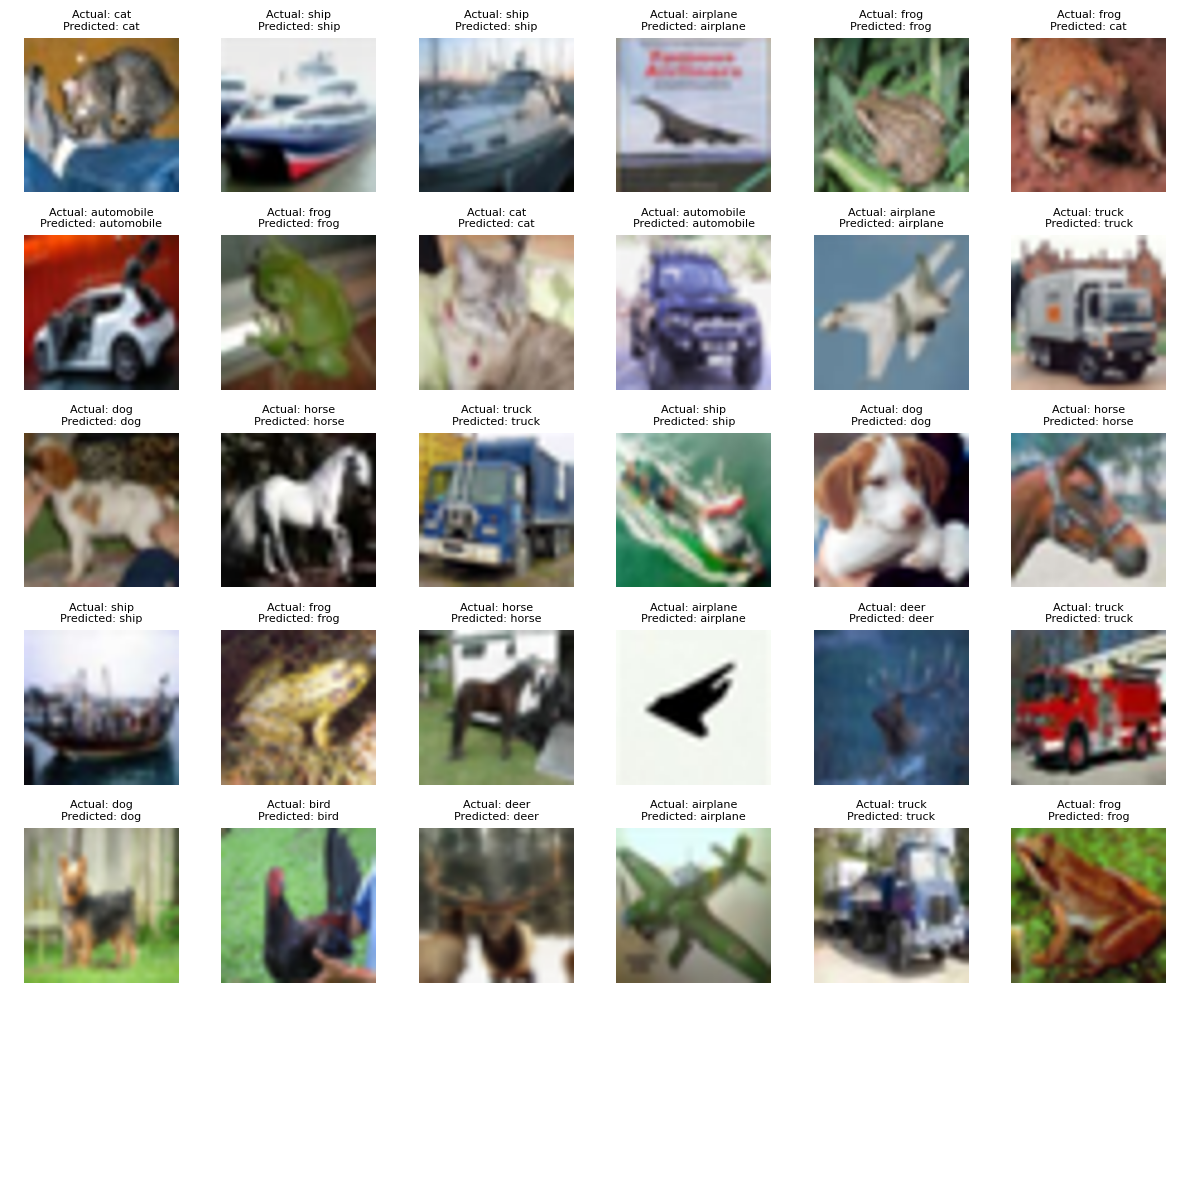

/tmp/ipykernel_4231/1293346789.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracies.append(float(correct_in_top_k.cpu().numpy()))


Top-1 accuracy: 89.83
Top-5 accuracy: 99.62


In [41]:
predictions = evaluate_and_visualize_model(model, loader, zeroshot_weights, visualize_predictions, accuracy, cifar10_classes)